# Domača naloga 2



## Naloga 1: Izbira modelov

##### 1.a: Spodnja slika prikazuje odločitvene krivulje (odločitvene meje) štirih modelov na isti podatkovni množici za binarno klasifikacijo z $D_Y = \{0, 1\}$. Krivulje so podane kot graf verjetnosti za vrednost ciljne spremenljivke 1, $P(Y=1)$. Za vsako sliko:

1. Identificiraj, kateri model (izmed tistih, ki smo jih delali na vajah in so lahko nelinearni brez spreminjanja podatkov) je ustvaril to odločitveno krivuljo.
2. Razloži, zakaj je ta odločitvena krivulja značilna za ta model.
3. Predlagaj vsaj eno konkretno spremembo, ki bi model naredila bolj točen na testnih podatkih in/ali bolj stabilen.
4. Razloži, kako bi spremembe vplivale na odločitveno krivuljo.

![Odločitvene krivulje modelov](1a_modeli.png)

**Odgovor**:

- Model A:
    - Ime modela: SVM (s jedrom iz radialnih baznih funkcij)
    - Zakaj si model izbral: SVM z RBF jedrom je zmožen se prilagodit skoraj vsaki obliki, kar je modelu v A primeri uspelu, kjub kompleksnosti in nelinearnosti podatkov.
    - Kako bi ga izboljšal: Pri trenutnem modelu izgleda kot, če prihaj do overfittinga, zato bi zmanjšal vrednost parametra C. S tem bi dosegel boljšo posplošitev modela
    - Kako bi to vplivalo na krivuljo: Krivulja bi bila bolj gladka in preprosta v primerjavi s trenutno, ki je zavita in kompleksna.

- Model B:
    - Ime modela: Naključni gozd
    - Zakaj si model izbral: Odločitveno drevo in naključni gozd (ki je zgrajen iz odl dreves) ti lahko narišeta 
    samo vodorvane in navpične meje, zato sta to prva kandidata za identificirnaje modela B. Ko pa gremo en korak naprej in model B primerjamo z modelom C (ki je tudi ali odl drevo ali naklj gozd, zaradi značilnih mej) postane očitno, da je model B naklj gozd. Razlog za tem so gladke meje, ki so posledica glasovanja večih odl dreves. Temno rdeča in bela barva, torej pomenita, da so več ali manj vsi model enako glasovali, svetlejši odtenki pa pomenijo, da je bilo manj soglasja med modeli.
    - Kako bi ga izboljšal: Možne stvari za modificirat so npr.: število dreves, maksimalno število značilk, ki ga dobi posamezno drevo, globina posameznega drevesa. Jaz bi v tem primeru **povečal število dreves**, ampak ne za veliko.
    - Kako bi to vplivalo na krivuljo: Po mojem mnenju je trenuten model dober, ampak preveč negotov (svetle barve zavamejo prevelik delež polja). Povečanje št dreves bi pomenilo zmanjšanje površine svetlih območji. Meje bi postale bolj gladke in jasne (model je bolj prepričan v svojo napoved). 

- Model C:
    - Ime modela: Odločitveno drevo
    - Zakaj si model izbral: Kot sem že prej omenil imata odl drevo in nakjl gozd samo vodoravne in navpične meje. Model C pa v primerjavi s modelom B nima odsekov kje bi bila površina svetlega odtenka (kje modelova klasifikacija ni stroga). Moje so torej posledica odločitve enega modela ne večih kot je to pri naključnem gozdu, torej je edini možen model v tem primeru odločitveno drevo.
    - Kako bi ga izboljšal: Model je očitno prevče prilagojen na podatke (overfitting). Zato bi uporabil sprotno ali naknadno rezanje drevesa in s tem preprečil preveliko prilagajanje.
    - Kako bi to vplivalo na krivuljo: Manj zapletenih kvadratnih vzorcev in bolj preproste meje

- Model D:
    - Ime modela: Logistična regresija
    - Zakaj si model izbral: v primerjavi z osatlimi slikami je to zdaleč najbolj prepost model, saj deli prostor na dva dela s linearno mejo značilno za linearne klasifikatorje kot log regersija. Poleg tega vidimo, da se barve ozadja postopoma spremnijajo s svetlega na temno, kar za log regres ni nenavadno. Ta namreč izračuna verjetnost, da posamezen primer pripada določeni klasi. Slika podobo pokaže, da bolj si oddaljen od linearne meje, večja je verjetnsot da ustrezaš določenemu razredu.
    - Kako bi ga izboljšal: Podatki niso linerano ločljivi, zato jih nobena ravna črta nebo popolnoma razdelila. Lahko bi uporabili polinmske značilke (npr kvadratne ali kubične), da bi se s tem model prilagodil tudi nelinearnim podatkom.
    - Kako bi to vplivalo na krivuljo: Meja bi posatala okrivljena. 

##### 1.b: Podani so štirje scenariji. Za vsak scenarij predlagaj, kako bi predlagani pristop izboljšal. Navedi konkretno spremembo in pojasni, zakaj bi ta sprememba pomagala. Odgovor zapiši kot komentar pod vsakim scenarijem.

Scenarij A: Ekipa podatkovnih inženirjev v finančnem podjetju je razvila model podpornih vektorjev (SVM) z linearnim jedrom za odkrivanje goljufivih bančnih transakcij. Podatki vsebujejo 500.000 transakcij (s podatki: id transakcije, čas transakcije, znesek transakcije, diskretna spremenljivka namen, podatki prejemnika, podatki pošiljatelja, ...), od katerih je le nekaj označenih za goljufive. Model je po treniranju dosegel skoraj popolno točnost na testnih podatkih, kar je ekipi dalo občutek, da je model izjemno uspešen. Po namestitvi v produkcijo so stranke začele poročati, da goljufive transakcije niso bile zaznane.

- Kaj je problem: problem je v tem, da je goljufivih transakcij zelo malo, zato tudi, če bi zgradili model, ki vedno napove transakcijo kot legitimno bi točnost bila zelo visoka, ampak model bi bil neuporaben za iskanje goljufivih transakcij.
- Kako bi ga popravil: Uporabil bi stratificirno vzorčenje. Tako ima model za vsak fold dovolj primerov obeh razredov, da se lahko nauči razliko med njima.
Še ena izboljašava bi bila uporabiti prilkic namesto točnost kot mero kakovosti, saj je ta za razliko od točnosti občutljiva na razrede, ki so v manjšini.

Scenarij B: Podjetje za nepremičnine želi napovedovati vrednosti stanovanj s pomočjo modela KNN ($k=5$). Model temelji na različnih lastnostih stanovanj (ki igrajo vlogo napovednih spremenljivk): število sob, površina v kvadratnih metrih, oddaljenost od centra mesta v minutah hoje, leto izgradnje, ... Kljub temu, da so podatki kakovostni, model dosega le skromne rezultate. Ekipa je preizkusila različne vrednosti $k$ od 1 do 30, a bistvenih izboljšav ni bilo.

- Kaj je problem: Kjučna težava je prekletstvo dimenzionalnosti.
Ker je značilk preveč, so razdalje med točkami skoraj enake in je posledično algoritem KNN neučinkovit.
Iz opisa scenarija sicer ne moramo razbrat, ampak sekundaren problem bi lahko bil, da podatki niso noramalizirani in potem imajo ene značilke večji vpliv kot druge. 
- Kako bi ga popravil: prekletsvo dimnezionalnosti bi rešil s PCA, da bi s tem zmanjšal dimnezionalnost na glavne komponente. Posledično bi model KNN bolje razlikoval med bližnjimi in oddaljenimi točkami.
Za nomralizacijo pa bi lahko uporabil npr. StandardScaler.

Scenarij C: Ekipa želi za napoved cene rabljenih avtomobilov izbrati najboljši model izmed petih kandidatov: linearne regresije, polinomskih regresij stopenj 2, 3 in 4 ter naključnega gozda. Na voljo imajo 400 primerov, ki jih razdelijo na 320 učnih in 80 testnih. Za vsakega kandidata izmerijo napako na testni množici in izberejo model z najnižjo izmerjeno napako — polinomsko regresijo stopnje 3 — ter napovejo, da bo ta model v produkciji dosegal enako napako. Njihov kolega opozori, da bo dejanska napaka v produkciji verjetno višja, a ekipa ne razume zakaj.

- Kaj je problem: Problem je, da izbiramo najboljši model glede na pre majhno testno množico. To da je v našem primeru polinomska regresija stopnje 3 ravno najboljši na tej testni množici je lahko čist slučajno.
- Kako bi ga popravil: Uporabil bi k-kratno prečno preverjanje in izbral model z najnižjo popvprečno napako. S tem dosežemo, da je ocena napake bolj zanesljiva.

Scenarij D: Analitiki v zavarovalnici so zgradili model za napoved verjetnosti prometne nesreče voznika v naslednjem letu, pri čemer je ciljna spremenljivka binarna (nesreča / ni nesreče). Podatki za napovedne spremenljivke so sestavljeni iz starosti voznika, povprečnega števila prevoženih kilometrov v zadnjih letih, avta, ki ga vozi, ... Za napovedovanje verjetnosti nesreče so uporabili linearno regresijo, naučeno na 50.000 primerih. Čeprav model dosega boljše rezultate kot prejšnji poskus, je pravna služba uporabo modela ustavila, saj ne zaupa napovedim, ki jih model vrača.

- Kaj je problem: Problem je v tem, da analitiki uporabljajo linearno regeresijo za problem klasifikacije. Linearna regersija lahko vrne vrednosti, ki ležijo izven interavala med 0 in 1, kar pa nima smisla za verjetnost. 
- Kako bi ga popravil: Uporabil bi logistično regresijo, saj je to model specifično namenjen za klasifikacijske probleme. Poleg tega log regresija dejansko izračuna vrejetnost, da posamezen primer spade v določen razred, zato je log regresija še toliko bolj smiselna rešitev.

## Naloga 2: Vrečenje z naključnimi podprostori

V tej nalogi boš implementiral metodo vrečenja (angl. _bagging, bootstrap aggregating_) za klasifikacijo brez uporabe vgrajene sklearn funkcije. Vrečenje trenira več enakih modelov na različnih vzorcih učnih podatkov in njihove napovedi združi z večinskim glasovanjem.

Podatki so iz podatkovne množice **Breast Cancer Wisconsin**, ki vsebuje 569 primerov, **30 napovednih spremenljivk** (pridobljenih iz slik celic tumorja) in 2 vrednosti ciljne spremenljivke (maligni / benigni tumor). Napovednih spremenljivk je (glede na število primerov) veliko in so organizirane v korelirane trojice (povprečje, standardna napaka in najslabša vrednost za vsako od 10 mer).

Najprej naložimo podatke.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt

In [4]:
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
feature_names = list(bc.feature_names)

X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_bc, y_bc, test_size=0.3, random_state=42
)
print(f"Učna množica: {X_w_train.shape[0]} primerov | Testna množica: {X_w_test.shape[0]} primerov")
print(f"Lastnosti ({len(feature_names)}): {feature_names}\n")

Učna množica: 398 primerov | Testna množica: 171 primerov
Lastnosti (30): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension')]



##### 2.a: Vzorčenje s ponavljanjem (angl. _bootstrap sampling_)

Implementiraj funkcijo `vzorci_z_vracanjem(X, y)`, ki vrne vzorec _bootstrap_ s ponavljanjem: naključno izbran vzorec iste velikosti kot vhodna podatkovna množica, pri katerem se isti primer se lahko pojavi večkrat; nekateri primeri morda sploh ne.

In [5]:
def vzorci_z_vracanjem(X: np.ndarray, y: np.ndarray):
    """Vrne bootstrap vzorec (vzorčenje z vračanjem) iste velikosti kot vhodni podatki."""
    # Dopolni
    indeksi = np.random.choice(X.shape[0], size=X.shape[0]) # parameter replace ima privzeto vrednost True
                                                            # kar bo nam omogočalo vzorčnje s povaljanjem
    X_vzorec = X[indeksi]
    y_vzorec = y[indeksi]

    return X_vzorec, y_vzorec

X_vzorec, y_vzorec = vzorci_z_vracanjem(X_w_train, y_w_train)
assert X_vzorec.shape == X_w_train.shape, f"Napačna oblika: {X_vzorec.shape}"
assert y_vzorec.shape == y_w_train.shape
print(f"Vzorec bootstrap: {X_vzorec.shape[0]} primerov. "
      f"Pričakovano ~{int(X_w_train.shape[0] * 0.632)} edinstvenih. "
      f"Dobljeno: {np.unique(X_vzorec, axis=0).shape[0]} edinstvenih")


Vzorec bootstrap: 398 primerov. Pričakovano ~251 edinstvenih. Dobljeno: 263 edinstvenih


##### 2.b: Naključni podprostor napovednih spremenljivk

Implementiraj funkcijo `nakljucni_podprostor(X, n_features)`, ki naključno izbere `n_features` stolpcev (napovednih spremenljivk) iz matrike X in vrne par `(X_sub, indices)`:
- `X_sub`: matrika z izbranimi stolpci
- `indices`: indeksi izbranih stolpcev (potrebni so pri napovedovanju, da izberemo pravi podprostor iz novih podatkov)

In [6]:
def nakljucni_podprostor(X: np.ndarray, n_features: int):
    """Vrne (X_sub, indices): naključno izbrane n_features lastnosti iz X."""
    # Dopolni
    indices = np.random.choice(X.shape[1], size=n_features, replace=False)
    X_sub = X[:, indices]
    return X_sub, indices

# Preverjanje
X_sub, idx_sub = nakljucni_podprostor(X_w_train, 5)
assert X_sub.shape == (X_w_train.shape[0], 5), f"Napačna oblika: {X_sub.shape}"
assert len(idx_sub) == 5
print(f"Podprostor: {X_sub.shape}, izbrani indeksi: {sorted(idx_sub.tolist())}\n")

Podprostor: (398, 5), izbrani indeksi: [2, 13, 17, 20, 24]



##### 2.c: Razred `VrecaModelov`

Implementiraj razred `VrecaModelov` (BaggingClassifier), ki gradi ansambel z vrečenjem odločitvenih dreves.

Parametri:
- `n_estimators` (int): število dreves v ansamblu,
- `max_features` (int ali None): število naključno izbranih lastnosti za vsako drevo; None pomeni, da se uporabijo vse lastnosti,
- `bootstrap` (bool): ali se primeri vzorčijo s ponavljanjem (ali brez).

Metoda `fit(X, y)`, ki za vsako drevo:
1. Vzorči primere z `vzorci_z_vracanjem` (če bootstrap=True), sicer vzemi vse.
2. Izberi naključni podprostor z `nakljucni_podprostor` (če max_features ni `None`, sicer pa vzemi vse napovedne spremenljivke).
3. Nauči `DecisionTreeClassifier` in ga shrani skupaj z indeksi izbranih napovednih spremenljivk.

Metoda `predict(X)`:
Za vsak primer v `X` zberi napovedi vseh dreves (pozor, vsako drevo naj napove na svojem podprostoru) in vrni vrednost ciljne spremenljivke, za katero je glasovala večina dreves.

Metoda `predict_proba(X)`:
Vrni matriko oblike (`n_primerov`, `n_razredov`), kjer vsaka vrstica vsebuje delež dreves, ki so glasovala za posamezen razred (vrednosti so iz intervala [0, 1] in se seštejejo v 1).


In [7]:
class VrecaModelov:
    """Ansambel odločitvenih dreves z vzorčenjem podatkov in/ali naključnim podprostorom."""

    def __init__(self, n_estimators: int = 50, max_features: int = None, bootstrap: bool = True):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.drevesa = []
        self.feature_indices = []
        self.classes_ = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        """Nauči ansambel dreves na (pod)vzorcih podatkov."""
        self.drevesa = []
        self.feature_indices = []
        self.classes_ = np.unique(y)
        # Dopolni
        for drevo in range(self.n_estimators): 

            if self.bootstrap:
                X_vzorec, y_vzorec = vzorci_z_vracanjem(X, y)
            else:
                X_vzorec, y_vzorec = X, y

            if self.max_features != None:
                X_sub, idx_sub = nakljucni_podprostor(X_vzorec, self.max_features)
            else: X_sub, idx_sub = X_vzorec, np.arange(X.shape[1])

            model = DecisionTreeClassifier().fit(X_sub, y_vzorec)
            self.drevesa.append(model)
            self.feature_indices.append(idx_sub)
        
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Napove razrede z večinskim glasovanjem vseh dreves."""
        # Dopolni
        napovedi = []

        for i in range(X.shape[0]):  # vsak primer
            glasovi = []
            for j in range(self.n_estimators):  # vsako drevo
                # značilke
                X_sub = X[i:i+1, self.feature_indices[j]]
                # napoved
                pred = self.drevesa[j].predict(X_sub)[0]
                glasovi.append(pred)
         
            unique, counts = np.unique(glasovi, return_counts=True)
            najpogosteje = unique[np.argmax(counts)]
            napovedi.append(najpogosteje)

        return np.array(napovedi)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Vrne verjetnosti razredov kot delež glasov; oblika (n_primerov, n_razredov)."""
        # Dopolni
        verjetnosti = []

        for i in range(X.shape[0]): # primer
            glasovi = []

            for j in range(self.n_estimators):  # drevo
                X_pod = X[i:i+1, self.feature_indices[j]]
                pred = self.drevesa[j].predict(X_pod)[0]
                glasovi.append(pred)

            verjetnosti_primera = np.zeros(len(self.classes_))

            for k, razred in enumerate(self.classes_):
                stevilo = np.sum(np.array(glasovi) == razred)
                verjetnosti_primera[k] = stevilo / self.n_estimators

            verjetnosti.append(verjetnosti_primera)

        return np.array(verjetnosti)
    
# Preverjanje pravilnosti VrecaModelov
np.random.seed(42)
_vm = VrecaModelov(n_estimators=50, bootstrap=True)
_vm.fit(X_w_train, y_w_train)

_pred = _vm.predict(X_w_test)
_proba = _vm.predict_proba(X_w_test)

assert _pred.shape == (X_w_test.shape[0],), \
    f"Napačna oblika predict: {_pred.shape}"
assert _proba.shape == (X_w_test.shape[0], len(np.unique(y_bc))), \
    f"Napačna oblika predict_proba: {_proba.shape}"
assert np.allclose(_proba.sum(axis=1), 1.0), \
    "Verjetnosti v vrsticah se ne seštejejo v 1"
assert np.array_equal(_pred, _vm.classes_[_proba.argmax(axis=1)]), \
    "predict in argmax(predict_proba) se ne ujemata"

_solo = DecisionTreeClassifier(random_state=42).fit(X_w_train, y_w_train)
assert accuracy_score(y_w_test, _pred) >= accuracy_score(y_w_test, _solo.predict(X_w_test)) - 0.05, \
    "VrecaModelov bistveno slabši od enega drevesa – preverite implementacijo"

print(f"Preverjanje VrecaModelov uspešno! "
      f"Točnost: {accuracy_score(y_w_test, _pred):.4f}, "
      f"oblika verjetnosti: {_proba.shape}, "
      f"primer verjetnosti (prva vrstica): {_proba[0].round(2)}")

Preverjanje VrecaModelov uspešno! Točnost: 0.9591, oblika verjetnosti: (171, 2), primer verjetnosti (prva vrstica): [0. 1.]


##### 2.d: Primerjava konfiguracij in korelacija dreves

Primerjaj štiri konfiguracije:
1. Eno odločitveno drevo
2. VrecaModelov (bootstrap=True,  max_features=None) – samo bootstrap
3. VrecaModelov (bootstrap=False, max_features=int(sqrt(30))) – samo podprostor lastnosti
4. VrecaModelov (bootstrap=True,  max_features=int(sqrt(30))) – kombinacija bootstrap in podprostor

Za vsako konfiguracijo:
- Izračunaj točnost na učni in testni množici ter AUC.
- Za vsako konfiguracijo izračunaj povprečno Pearsonovo korelacijo napovedi med drevesi iz ansambla na testni množici.
- Nariši histogram zaupanja (maksimalna verjetnost vrednosti ciljne spremenljivke) ločeno za pravilne in napačne napovedi.

Odgovori:
- Katera konfiguracija je najboljša in zakaj?
- Kako korelacija dreves vpliva na kakovost ansambla?
- Kaj histogram zaupanja pove o tem, kdaj model naredi napako?

In [8]:
np.random.seed(42)
n_feat_sqrt = int(np.sqrt(X_bc.shape[1])) 

In [9]:
# Eno določitveno drevo
model1 = DecisionTreeClassifier().fit(X_w_train, y_w_train)
y_pred_train = model1.predict(X_w_train)
y_pred_test = model1.predict(X_w_test)
y_pred_proba_train = model1.predict_proba(X_w_train)[:, 1]
y_pred_proba_test = model1.predict_proba(X_w_test)[:, 1]

print("Eno določitveno drevo")
print(f"Točnost na učni množici: {accuracy_score(y_w_train, y_pred_train)}")
print(f"Točnost na testni množici: {accuracy_score(y_w_test, y_pred_test)}")
print(f"AUC na učni množici: {roc_auc_score(y_w_train, y_pred_proba_train)}")
print(f"AUC na testni množici: {roc_auc_score(y_w_test, y_pred_proba_test)}\n")

# VrecaModelov - samo bootstrap
model2 = VrecaModelov(bootstrap=True, max_features=None).fit(X_w_train, y_w_train)
y_pred_train = model2.predict(X_w_train)
y_pred_test = model2.predict(X_w_test)
y_pred_proba_train = model2.predict_proba(X_w_train)[:, 1]
y_pred_proba_test = model2.predict_proba(X_w_test)[:, 1]

print("VrecaModelov - samo bootstrap")
print(f"Točnost na učni množici: {accuracy_score(y_w_train, y_pred_train)}")
print(f"Točnost na testni množici: {accuracy_score(y_w_test, y_pred_test)}")
print(f"AUC na učni množici: {roc_auc_score(y_w_train, y_pred_proba_train)}")
print(f"AUC na testni množici: {roc_auc_score(y_w_test, y_pred_proba_test)}\n")

# VrecaModelov - samo podprostor lastnosti
model3 = VrecaModelov(bootstrap=False, max_features=n_feat_sqrt).fit(X_w_train, y_w_train)
y_pred_train = model3.predict(X_w_train)
y_pred_test = model3.predict(X_w_test)
y_pred_proba_train = model3.predict_proba(X_w_train)[:, 1]
y_pred_proba_test = model3.predict_proba(X_w_test)[:, 1]

print("VrecaModelov - samo podprostor lastnosti")
print(f"Točnost na učni množici: {accuracy_score(y_w_train, y_pred_train)}")
print(f"Točnost na testni množici: {accuracy_score(y_w_test, y_pred_test)}")
print(f"AUC na učni množici: {roc_auc_score(y_w_train, y_pred_proba_train)}")
print(f"AUC na testni množici: {roc_auc_score(y_w_test, y_pred_proba_test)}\n")

# VrecaModelov - kombinacija bootstrap in podprostor
model4 = VrecaModelov(bootstrap=True, max_features=n_feat_sqrt).fit(X_w_train, y_w_train)
y_pred_train = model4.predict(X_w_train)
y_pred_test = model4.predict(X_w_test)
y_pred_proba_train = model4.predict_proba(X_w_train)[:, 1]
y_pred_proba_test = model4.predict_proba(X_w_test)[:, 1]

print("VrecaModelov - kombinacija bootstrap in podprostor")
print(f"Točnost na učni množici: {accuracy_score(y_w_train, y_pred_train)}")
print(f"Točnost na testni množici: {accuracy_score(y_w_test, y_pred_test)}")
print(f"AUC na učni množici: {roc_auc_score(y_w_train, y_pred_proba_train)}")
print(f"AUC na testni množici: {roc_auc_score(y_w_test, y_pred_proba_test)}")

Eno določitveno drevo
Točnost na učni množici: 1.0
Točnost na testni množici: 0.9415204678362573
AUC na učni množici: 1.0
AUC na testni množici: 0.9437830687830687

VrecaModelov - samo bootstrap
Točnost na učni množici: 1.0
Točnost na testni množici: 0.9590643274853801
AUC na učni množici: 1.0
AUC na testni množici: 0.9914021164021164

VrecaModelov - samo podprostor lastnosti
Točnost na učni množici: 1.0
Točnost na testni množici: 0.9707602339181286
AUC na učni množici: 1.0
AUC na testni množici: 0.996252204585538

VrecaModelov - kombinacija bootstrap in podprostor
Točnost na učni množici: 1.0
Točnost na testni množici: 0.9649122807017544
AUC na učni množici: 1.0
AUC na testni množici: 0.9961787184009406


**Katera konfiguracija je najboljša in zakaj?**
- Najboljši sta konfiguraciji modelov 3 in 4 (torej samo podprostor lastnosti ali kombinacija bootstrapa in podprostora), ker imata najvišjo točnost in AUC na test množici. 

In [10]:
# Povp. Pearsonova korelacija napovedi med drevesi
print("POVPREČNA PEARSONOVA KORELACIJA NAPOVEDI MED DREVESI")

# VrecaModelov - samo bootstrap
napovedi_dreves = []
for i in range(model2.n_estimators):
    pred = model2.drevesa[i].predict(X_w_test[:, model2.feature_indices[i]])
    napovedi_dreves.append(pred)

napovedi_dreves = np.array(napovedi_dreves)
# korelacijska matrika
kor_matrika = np.corrcoef(napovedi_dreves)
# popv korelacija
povp_korelacija_model2 = np.mean(kor_matrika[np.triu_indices_from(kor_matrika, k=1)])

print(f"VrecaModelov - samo bootstrap: {povp_korelacija_model2}")

# VrecaModelov - samo podprostor lastnosti
napovedi_dreves = []
for i in range(model3.n_estimators):
    pred = model3.drevesa[i].predict(X_w_test[:, model3.feature_indices[i]])
    napovedi_dreves.append(pred)

napovedi_dreves = np.array(napovedi_dreves)
# korelacijska matrika
kor_matrika = np.corrcoef(napovedi_dreves)
# popv korelacija
povp_korelacija_model3 = np.mean(kor_matrika[np.triu_indices_from(kor_matrika, k=1)])

print(f"VrecaModelov - samo podprostor lastnosti: {povp_korelacija_model3}")

# VrecaModelov - kombinacija bootstrap in podprostor
napovedi_dreves = []
for i in range(model4.n_estimators):
    pred = model4.drevesa[i].predict(X_w_test[:, model4.feature_indices[i]])
    napovedi_dreves.append(pred)

napovedi_dreves = np.array(napovedi_dreves)
# korelacijska matrika
kor_matrika = np.corrcoef(napovedi_dreves)
# popv korelacija
povp_korelacija_model4 = np.mean(kor_matrika[np.triu_indices_from(kor_matrika, k=1)])

print(f"VrecaModelov - kombinacija bootstrap in podprostor: {povp_korelacija_model4}")

POVPREČNA PEARSONOVA KORELACIJA NAPOVEDI MED DREVESI
VrecaModelov - samo bootstrap: 0.8137628454087312
VrecaModelov - samo podprostor lastnosti: 0.7371865891044728
VrecaModelov - kombinacija bootstrap in podprostor: 0.6651725016013227


**Kako korelacija dreves vpliva na kakovost ansambla?**
- Iz izračunanih korelacij lahko razberemo, da manjša korelacija dreves pomeni višja kakovost ansambla.

MAKSIMALNE VERJETNOSTI

Model 1: Eno drevo:
  Pravilne napovedi: povprečje=1.0, std=0.0, n=161
  Napačne napovedi: povprečje=1.0, std=0.0, n=10

Model 2: Samo bootstrap:
  Pravilne napovedi: povprečje=0.9499999999999998, std=0.09841425635373433, n=164
  Napačne napovedi: povprečje=0.7142857142857143, std=0.13678524804098083, n=7

Model 3: Samo podprostor:
  Pravilne napovedi: povprečje=0.9273493975903614, std=0.10542609285112471, n=166
  Napačne napovedi: povprečje=0.668, std=0.032496153618543834, n=5

Model 4: Bootstrap in podprostor:
  Pravilne napovedi: povprečje=0.9093333333333333, std=0.10082167475801074, n=165
  Napačne napovedi: povprečje=0.6266666666666667, std=0.06182412330330469, n=6



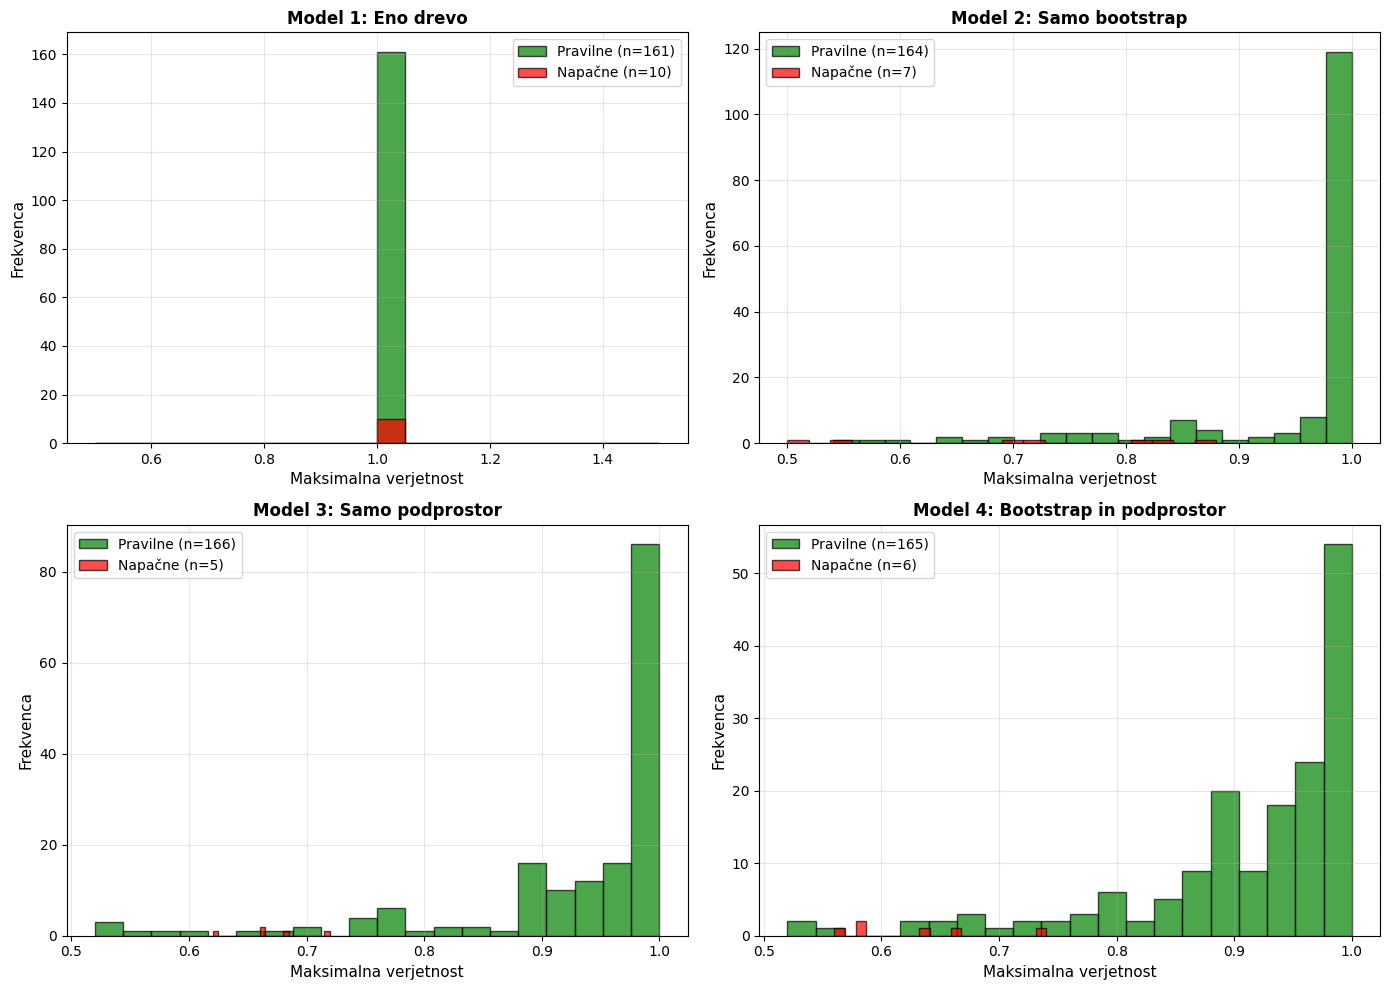

In [11]:
# Histogram zaupanja
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

modeli = [model1, model2, model3, model4]
imena = ["Model 1: Eno drevo", "Model 2: Samo bootstrap",
         "Model 3: Samo podprostor", "Model 4: Bootstrap in podprostor"
]

print("MAKSIMALNE VERJETNOSTI\n")

for idx, (model, ime) in enumerate(zip(modeli, imena)):
    # napovedi
    y_pred = model.predict(X_w_test)
    # verjetnosti
    y_proba = model.predict_proba(X_w_test)
    # max verjetnost za vsak primer
    max_verjetnost = np.max(y_proba, axis=1)

    pravilne = max_verjetnost[y_pred == y_w_test]
    napacne = max_verjetnost[y_pred != y_w_test]
    
    print(f"{ime}:")
    print(f"  Pravilne napovedi: povprečje={np.mean(pravilne)}, std={np.std(pravilne)}, n={len(pravilne)}")
    if len(napacne) > 0:
        print(f"  Napačne napovedi: povprečje={np.mean(napacne)}, std={np.std(napacne)}, n={len(napacne)}")
    else:
        print(f"  Napačne napovedi: ni napačnih napovedi!")
    print()
    
    # histogrami
    ax = axes[idx]
    ax.hist(pravilne, bins=20, alpha=0.7, label=f'Pravilne (n={len(pravilne)})', 
            color='green', edgecolor='black')
    if len(napacne) > 0:
        ax.hist(napacne, bins=20, alpha=0.7, label=f'Napačne (n={len(napacne)})', 
                color='red', edgecolor='black')
    
    ax.set_xlabel('Maksimalna verjetnost', fontsize=11)
    ax.set_ylabel('Frekvenca', fontsize=11)
    ax.set_title(ime, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Kaj histogram zaupanja pove o tem, kdaj model naredi napako?**
- Za modela 3 in 4 nam histogram zaupanja pove, da naredita napako samo, ko sta negotoviva pri svoji napovedi (zato je večino rdečih stolpcev boj levo na x osi), kar je dobro.
- Pri modelu 1 je rdeč stolpec okrog vrednsoti 1.0, kar je slabo, saj model narobe klasificra primer kljub temu, da je prepričan v pravilnost svojega odgovora.
- Za model 2 pa so napačne klasifikacije bolj enakomerno razpršene glede na maksimalno verjetnost, kar ni slabo a hkrati ni idelano.

##### 2.e: Napovedna moč spremenljivk

Iz konfiguracije bootstrap + podprostor (100 dreves) izračunaj povprečno napovedno moč vsake od 30 napovednih spremenljivk čez vsa drevesa ansambla in jo vizualiziraj s stolpčnim diagramom.

Odgovori: katere 3 napovedne spremenljivke so najpomembnejše (imajo največjo napovedno moč)?

3 najpomejbnejše napovedne spremenljivke:
1. mean concave points: 0.1209
2. worst area: 0.1068
3. worst concave points: 0.0908


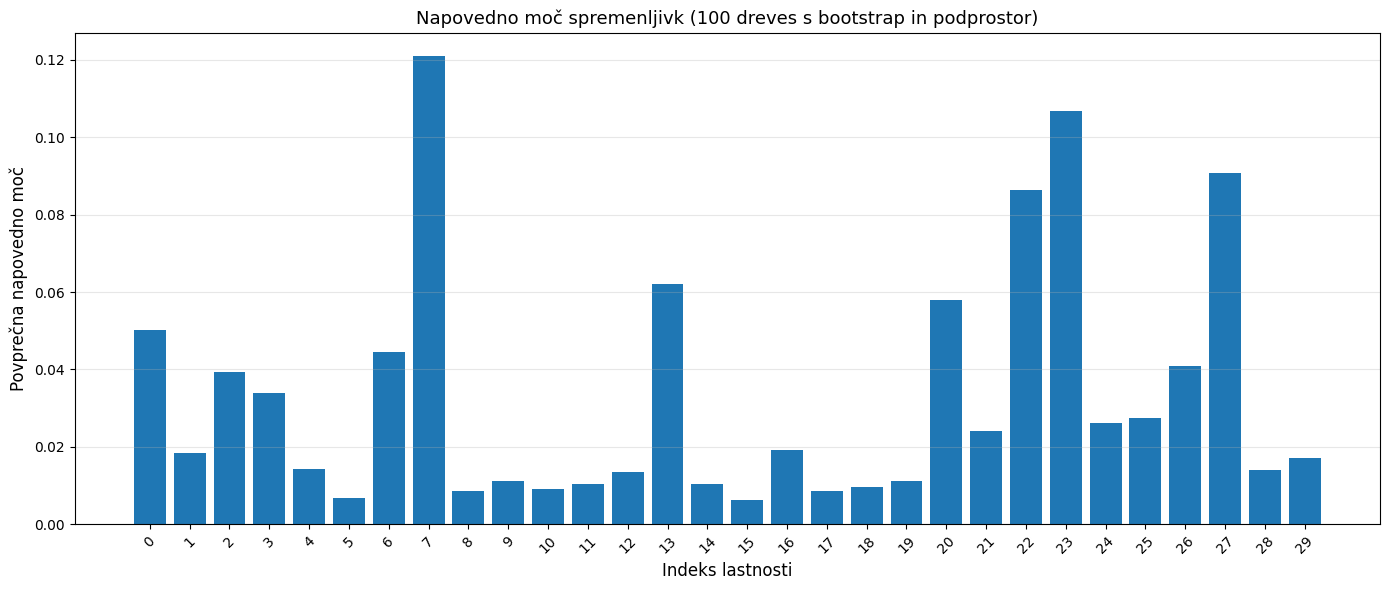

In [12]:
# VrecaModelov - kombinacija bootstrap in podprostor (100 dreves)
model4_100 = VrecaModelov(bootstrap=True, n_estimators=100, max_features=n_feat_sqrt).fit(X_w_train, y_w_train)

matrika_importance = np.zeros((model4_100.n_estimators, X_bc.shape[1]))

for i in range(model4_100.n_estimators):
    drevo = model4_100.drevesa[i]
    indeksi = model4_100.feature_indices[i]
    matrika_importance[i, indeksi] = drevo.feature_importances_

povprecna_importance = np.mean(matrika_importance, axis=0)

top_3_indeksi = np.argsort(povprecna_importance)[-3:][::-1]
print("3 najpomejbnejše napovedne spremenljivke:")
for rang, idx in enumerate(top_3_indeksi, 1):
    print(f"{rang}. {feature_names[idx]}: {povprecna_importance[idx]:.4f}")

plt.figure(figsize=(14, 6))
plt.bar(range(X_bc.shape[1]), povprecna_importance)
plt.xlabel("Indeks lastnosti", fontsize=12)
plt.ylabel("Povprečna napovedno moč", fontsize=12)
plt.title("Napovedno moč spremenljivk (100 dreves s bootstrap in podprostor)", fontsize=13)
plt.xticks(range(X_bc.shape[1]), rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Naloga 3: Klasifikacija oblačil s slikovnimi podatki

Analiziraj podatke iz podatkovne množice **Fashion-MNIST** in sestavi napovedni model, ki bo čim boljše klasificiral slike oblačil v 10 razredov. Poskrbi, da poleg ocene zmogljivosti modela poročaš tudi o **stabilnosti ocene**. Opiši tvoj izbrani model ter kako in zakaj si se odločal/a pri vsakem vidiku njegove zasnove (arhitektura, hiperparametri, regularizacija). Opiši tudi modele in arhitekture, ki si jih poskusil/a, a jih nisi izbral/a, ker niso dosegali zmogljivosti izbranega modela.

Zgraditi moraš nevronsko mrežo s knjižnico PyTorch in jo primerjati z vsaj enim ne-nevronskim modelom (npr. naključni gozd ali SVM). Kot mero zmogljivosti lahko uporabiš poljubno mero za večrazredno klasifikacijo, ki smo jo obravnavali na predavanjih in/ali vajah. Obrazloži svojo izbiro mere zmogljivosti.

**Podatkovna množica** vsebuje slike oblačil velikosti 28x28 točk (za vsako točko je na voljo intenziteta sive barve) iz 10 razredov: Majica, Hlače, Pulover, Obleka, Plašč, Sandal, Srajca, Superga, Torba, Škorenj. Za hitrejše treniranje na prenosnikih bomo uporabili spodaj vzorčeno razdelitev na učne in testne podatke: 10.000 učnih in 2.000 testnih primerov (naključno izbranih).

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

RAZREDI = ['Majica', 'Hlače', 'Pulover', 'Obleka', 'Plašč', 'Sandal', 'Srajca', 'Superga', 'Torba', 'Škorenj']

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_polni = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_polni  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

np.random.seed(42)
train_idx_nn = np.random.choice(len(train_polni), 10000, replace=False)
test_idx_nn  = np.random.choice(len(test_polni),   2000, replace=False)

train_set = Subset(train_polni, train_idx_nn.tolist())
test_set  = Subset(test_polni,  test_idx_nn.tolist())

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)

#### Izbira mere zmoglivosti 
Ker je naš cilj narediti model, ki čim bolj klasificira slike v pravilne razrede se je mere **točnost** zdela kot naravna izbira. 

### Konvolucijska nevrosnka mreža
Poskusil sem različne konfiguracije konvolucijskih nevronskih mrež, saj so te prav zasnovane za obdelavo 2D slik.
#### Konfiguracija najboljše nevronske mreže, ki sem jo testiral
Med spodaj testiranimi nevrosnkimi mrežami je najbojše delovala **sedma**.  
Arhitektura: 
- tri konvolucijski sloji,
- 64 filtrov na prvem konv sloju (sem dobil večjo točnost kot s 16 in 32 filtri.),
- BatchNormalization po vsakem Conv2d (za stabilnejše učenje).      

Hiperparametri:
- learning rate: 0.01,
- optimizator SGD (Adam ni dal boljših rezultatov),
- batch size: 32,
- število epoch: 5,
- kernel size: 3×3,
- padding: 1

Regularizacija:
- BatchNorm2d,
- Dropout nastavljen na 0.5 (za zmanjšanje overfittinga),
- MaxPool2d (2x2).

Rezultati:
- Točnost: povprečna točnost na petih različnih random seed-ih je 0.8526.
- Stabilnost: model je stabilen. Standarndi odklon pri rač. točnosti na petih random seed-ih je 0.0075.

Kaj ni delovalo:
- povečanje števila konv slojev brez tega, da bi dodal Dropout in BatchNorm2d za preprečevanje overfittinga,
- opitimizator Adam ni delovalo bolje od SGD,
- preprosta nm s samo enim konv slojem, brez Dropout in BatchNorm2d.

#### Postopek testiranja različnih nevronskih mrež

In [14]:
from tqdm import tqdm

# Naredimo funkcijo, ki bo natrenirala naš model (vzel iz Vaje 7)
def train(epochs, model, trainset, batch_size, learning_rate=0.01):
    
    # Najprej definiramo objekt s katerim bomo vzorčili podatke. Nevronske mreže se ponavadi uči iterativno, več epoh in znotraj vsake epohe več iteracij
    # V vsaki iteraciji se učimo iz ene skupine podatkov (ang. batch)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    
    # Zagotovimo, da bo model v načinu treniranja, kjer se računajo gradienti in so aktivni vsi sloji (med evalvacijo niso nujno vsi aktivni, npr. Dropout, BatchNormalization, ...)
    model.train()
    
    # Definiramo naš optimizator. V našem primeru bo to stohastični gradientni spust (SGD) z learning rate-om 0.01
    # Lahko bi uporabili tudi Adam naprimer
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    # Definiramo našo funkcijo izgube (loss). V našem primeru bo to prečna entropija.
    criterion = nn.CrossEntropyLoss()
    
    # Gremo čez epohe
    for epoch in range(epochs):

        running_loss = 0.0
        # Uporabimo funkcijo tqdm.tqdm, ki nam bo lepše, v realnem času izpisovala napredek učenja
        with tqdm(total=len(trainloader)*batch_size, desc=f'Training - Epoch: {epoch + 1}/{epochs}', unit='chunks') as prog_bar:
            # Gremo čez vse podatke v skupinah po batch_size z trainloaderjem, v našem primeru je to 32
            for i, data in enumerate(trainloader, 0):
                # Podatke razpakiramo v vhode in izhode (labele)
                inputs, labels = data

                # Počistimo (resetiramo) gradiente v podatkih
                optimizer.zero_grad()

                # Vhodne podatke spustimo čez model, ta nam vrne matriko, v kateri se vsaka vrstica sešteje v 1 (zaradi Softmax sloja)
                outputs = model(inputs)
                # Izračunamo izgubo
                loss = criterion(outputs, labels)
                # Naredimo vzvratno razširanje napake (backpropagation)
                loss.backward()
                # Naredimo en korak optimizacije
                optimizer.step()

                # Dodamo izgubo k naši vsoti izgube. S funkcijo detach poskrbimo, da ne prištejemo (in si tako shranimo) tudi gradienta
                # s funkcijo item() pa da se le vrednost in ne celoten vektor
                running_loss += loss.detach().item()

                # Posodobimo vrednosti funkcije tqdm.tqdm. Vsoto dosedanje izgube delimo s številom skupin, ki smo jih že obdelali
                prog_bar.set_postfix(**{'loss': (running_loss) / (i+1)})
                # Posodobimo progress bar
                prog_bar.update(batch_size)

    print('Finished Training')

In [15]:
# Funkcija za testiraj modela (vzel iz Vaje 7)
def test(model, testset, batch_size):
    
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    # Model damo v način evalvacije. Tu se gradienti ne računajo in da se nekateri sloji deaktivirajo
    model.eval()
    test_loss = 0
    correct = 0
    counter = 0
    
    # Dodatno poskrbimo, da vektorji ne vsebujejo gradientov
    with torch.no_grad():
        with tqdm(total=len(testloader)*batch_size, desc=f'Testing', unit='chunks') as prog_bar:
            for i, data in enumerate(testloader, 0):
                inputs, labels = data
                output = model(inputs)
                test_loss += criterion(output, labels).detach().item()
                # Izberemo indekse mesta z najvišjo vrednostjo ("verjetnostjo")
                pred = output.data.max(1, keepdim=True)[1]
                # Prištejemo število primerov, kjer smo zadeli pravilno števko
                correct += pred.eq(labels.data.view_as(pred)).sum()
                prog_bar.update(batch_size)
                counter += 1
    
    print(f'Test set: Avg. loss: {test_loss/counter}, Correct predictions: {correct}/{len(testloader.dataset)}')

#### 1. nevronska mreža
Prvo sem naredil konv. nm podobno tisti, ki smo jo naredili na vajah 7.

In [16]:
class CNN1(nn.Module):
    def __init__(self):
        super(CNN1, self).__init__()

        self.convolution = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2))
        # Na koncu bomo ciljno vrednost napovedali s polno povezanim slojem. 
        self.fc = nn.Linear(16*14*14, 10)
    
    def forward(self, x):
        x = self.convolution(x)
        x = x.reshape(x.size(0), -1)
        # Napovemo ciljno vrednost 
        x = self.fc(x)
        return x


In [17]:
torch.manual_seed(42)
model = CNN1()
epochs = 5
batch_size = 32

print("Accuracy on the test set before training")
print(end="")
test(model, test_set, batch_size)
print()

train(epochs, model, train_set, batch_size)
print()

print("Accuracy on the test set after training the model")
test(model, test_set, batch_size)

Accuracy on the test set before training


Testing:   0%|          | 0/2016 [00:00<?, ?chunks/s]

Testing: 100%|██████████| 2016/2016 [00:00<00:00, 4431.69chunks/s]


Test set: Avg. loss: 2.3763212892744274, Correct predictions: 164/2000



Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:03<00:00, 3330.53chunks/s, loss=0.454]


Finished Training

Accuracy on the test set after training the model


Testing: 100%|██████████| 2016/2016 [00:00<00:00, 7781.50chunks/s]

Test set: Avg. loss: 0.49878435475485666, Correct predictions: 1646/2000


#### 2. nevronska mreža
Drugo nm sem zgradil s 4 konvolucijskimi slojami.

In [18]:
class CNN2(nn.Module):
    def __init__(self):
        super(CNN2, self).__init__()

        self.convolution = nn.Sequential(
            # 1. konv. sloj
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 2. konv. sloj
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 3. konv. sloj
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            # 4. konv. sloj
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.fc = nn.Linear(64*7*7, 10)
        
        
    
    def forward(self, x):
        x = self.convolution(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

In [19]:
torch.manual_seed(42)
model = CNN2()
epochs = 5
batch_size = 32

print("Accuracy on the test set before training")
print(end="")
test(model, test_set, batch_size)
print()

train(epochs, model, train_set, batch_size)
print()

print("Accuracy on the test set after training the model")
test(model, test_set, batch_size)

Accuracy on the test set before training


Testing: 100%|██████████| 2016/2016 [00:00<00:00, 2219.31chunks/s]


Test set: Avg. loss: 2.3046298746078735, Correct predictions: 175/2000



Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:06<00:00, 1524.55chunks/s, loss=0.58]


Finished Training

Accuracy on the test set after training the model


Testing: 100%|██████████| 2016/2016 [00:00<00:00, 3866.89chunks/s]

Test set: Avg. loss: 0.6304343295475793, Correct predictions: 1528/2000


#### 3. nevronska mreža
Ker dodajanje konvolucijskih slojev ni pomagalo sem modelu z enim konv slojem dodal Dropout sloj (za stabilnost in hitrejše učenje) in BachNormalization sloj (za preprečevanje overfittinga). V polno povezanem delu sem tudi dodal en vmesni sloj za boljše učenje kompleksnejših, nelinearnih vzorcev.

In [20]:
class CNN3(nn.Module):
    def __init__(self):
        super(CNN3, self).__init__()

        self.convolution = nn.Sequential(
            # Povačal sem še št. filtrov s 16 na 32 na prvem konv sloju
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) 
        )
        
        self.fc = nn.Sequential(
            nn.Linear(32*14*14, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.convolution(x)
        x = x.reshape(x.size(0), -1)
        x = self.fc(x)
        return x

In [21]:
torch.manual_seed(42)
model = CNN3()
epochs = 5
batch_size = 32

print("Accuracy on the test set before training")
print(end="")
test(model, test_set, batch_size)
print()

train(epochs, model, train_set, batch_size)
print()

print("Accuracy on the test set after training the model")
test(model, test_set, batch_size)

Accuracy on the test set before training


Testing: 100%|██████████| 2016/2016 [00:00<00:00, 5763.26chunks/s]


Test set: Avg. loss: 2.3111021480863054, Correct predictions: 206/2000



Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:03<00:00, 2681.72chunks/s, loss=0.351]


Finished Training

Accuracy on the test set after training the model


Testing: 100%|██████████| 2016/2016 [00:00<00:00, 5560.49chunks/s]

Test set: Avg. loss: 0.4025957590294263, Correct predictions: 1722/2000


#### 4. nevronska mreža
Prejšnji model je boljši od prvega in drugega. Naslednjemu modelu sem dodal še en konvolucijski sloj in maxpooling sloj.

In [22]:
class CNN4(nn.Module):
    def __init__(self):
        super(CNN4, self).__init__()

        self.convolution = nn.Sequential(
            # 1. konv sloj
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 2. konv sloj
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) 
        )
        
        self.fc = nn.Sequential(
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.convolution(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        return x

In [23]:
torch.manual_seed(42)
model = CNN4()
epochs = 5
batch_size = 32

print("Accuracy on the test set before training")
print(end="")
test(model, test_set, batch_size)
print()

train(epochs, model, train_set, batch_size)
print()

print("Accuracy on the test set after training the model")
test(model, test_set, batch_size)

Accuracy on the test set before training


Testing: 100%|██████████| 2016/2016 [00:00<00:00, 3411.51chunks/s]


Test set: Avg. loss: 2.3028031038859536, Correct predictions: 277/2000



Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:06<00:00, 1521.49chunks/s, loss=0.342]


Finished Training

Accuracy on the test set after training the model


Testing: 100%|██████████| 2016/2016 [00:00<00:00, 3094.35chunks/s]

Test set: Avg. loss: 0.3920085397031572, Correct predictions: 1720/2000


Bistvene razlike glede točnosti ni.

#### 5. nevrosnka mreža 
Prejšnjemu modelu sem povečal število filtrov na prvem konvolucijskem sloju.

In [24]:
class CNN5(nn.Module):
    def __init__(self):
        super(CNN5, self).__init__()

        self.convolution = nn.Sequential(
            # 1. konv sloj
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 2. konv sloj
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) 
        )
        
        self.fc = nn.Sequential(
            nn.Linear(128*7*7, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.convolution(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        return x

In [25]:
torch.manual_seed(42)
model = CNN5()
epochs = 5
batch_size = 32

print("Accuracy on the test set before training")
print(end="")
test(model, test_set, batch_size)
print()

train(epochs, model, train_set, batch_size)
print()

print("Accuracy on the test set after training the model")
test(model, test_set, batch_size)

Accuracy on the test set before training


Testing:   0%|          | 0/2016 [00:00<?, ?chunks/s]

Testing: 100%|██████████| 2016/2016 [00:01<00:00, 1911.05chunks/s]


Test set: Avg. loss: 2.3096657556200784, Correct predictions: 242/2000



Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:11<00:00, 844.34chunks/s, loss=0.306]


Finished Training

Accuracy on the test set after training the model


Testing: 100%|██████████| 2016/2016 [00:01<00:00, 1750.05chunks/s]

Test set: Avg. loss: 0.3467986136674881, Correct predictions: 1753/2000


#### 6. nevronska mreža
Model nisem spremenil, ampak sem v funkciji train zamanjela optimizator na Adam.

In [26]:
# optimizator Adam 

def train_adam(epochs, model, trainset, batch_size, learning_rate=0.01):
    
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    
    model.train()
    
    # Tukaj je sprememba od prejšnje train funkcije
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):

        running_loss = 0.0

        with tqdm(total=len(trainloader)*batch_size, desc=f'Training - Epoch: {epoch + 1}/{epochs}', unit='chunks') as prog_bar:
            
            for i, data in enumerate(trainloader, 0):
            
                inputs, labels = data

                optimizer.zero_grad()

                outputs = model(inputs)

                loss = criterion(outputs, labels)
                
                loss.backward()
                
                optimizer.step()

                running_loss += loss.detach().item()

                prog_bar.set_postfix(**{'loss': (running_loss) / (i+1)})

                prog_bar.update(batch_size)

    print('Finished Training')

In [27]:
torch.manual_seed(42)
model = CNN5()
epochs = 5
batch_size = 32

print("Accuracy on the test set before training")
print(end="")
test(model, test_set, batch_size)
print()

train_adam(epochs, model, train_set, batch_size)
print()

print("Accuracy on the test set after training the model")
test(model, test_set, batch_size)

Accuracy on the test set before training


Testing:   0%|          | 0/2016 [00:00<?, ?chunks/s]

Testing: 100%|██████████| 2016/2016 [00:01<00:00, 1816.11chunks/s]


Test set: Avg. loss: 2.3096657556200784, Correct predictions: 242/2000



Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:20<00:00, 495.81chunks/s, loss=0.46]


Finished Training

Accuracy on the test set after training the model


Testing: 100%|██████████| 2016/2016 [00:01<00:00, 1444.17chunks/s]

Test set: Avg. loss: 0.44823207552470856, Correct predictions: 1681/2000


#### 7. nevrosnka mreža 
Ker optimizator Adam ni pomagal sem ga odstranil in modelu 5 dodal še tretji konv sloj in Dropout povečal z 0.3 na 0.5.

In [28]:
# 7. enakoo kot model 5 samo da dodamo še en konvoluvijski sloj in povečamo dropout

class CNN7(nn.Module):
    def __init__(self):
        super(CNN7, self).__init__()

        self.convolution = nn.Sequential(
            # 1. konv sloj
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 2. konv sloj
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) ,
            # 3. konv sloj
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.fc = nn.Sequential(
            nn.Linear(256*3*3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.convolution(x)
        x = x.view(x.size(0), -1) 
        x = self.fc(x)
        return x

In [29]:
torch.manual_seed(42)
model = CNN7()
epochs = 5
batch_size = 32

print("Accuracy on the test set before training")
print(end="")
test(model, test_set, batch_size)
print()

train(epochs, model, train_set, batch_size)
print()

print("Accuracy on the test set after training the model")
test(model, test_set, batch_size)

Accuracy on the test set before training


Testing:   0%|          | 0/2016 [00:00<?, ?chunks/s]

Testing: 100%|██████████| 2016/2016 [00:01<00:00, 1013.48chunks/s]


Test set: Avg. loss: 2.3031772658938454, Correct predictions: 180/2000



Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:19<00:00, 521.77chunks/s, loss=0.325]


Finished Training

Accuracy on the test set after training the model


Testing: 100%|██████████| 2016/2016 [00:01<00:00, 1018.72chunks/s]

Test set: Avg. loss: 0.35892035055255134, Correct predictions: 1740/2000


#### Točnost in stabilnost 7. nevronske mreže

In [30]:
# Varianca CNN7 - 5 treningov z različnimi seeds
results = []
seeds = [42, 66, 12, 7, 100]
 
for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model = CNN7()
    epochs = 5
    batch_size = 32
    
    print(f"\nSeed {seed}")
    train(epochs, model, train_set, batch_size)
    # Test in shranimo si točnost
    testloader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)
    model.eval()
    correct = 0
    
    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs)
            pred = outputs.data.max(1, keepdim=True)[1]
            correct += pred.eq(labels.data.view_as(pred)).sum().item()
    
    accuracy = correct / len(test_set)
    results.append(accuracy)
    print(f"Accuracy: {accuracy:.4f}")
    
# Rezultati
print("\nRezultati 7. nevrosnke mreže")
print(f"Povprečje petih točnosti: {np.mean(results)}")
print(f"Standardni odklon (stabilnost): {np.std(results)}")


Seed 42


Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:19<00:00, 523.17chunks/s, loss=0.329]


Finished Training
Accuracy: 0.8525

Seed 66


Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:17<00:00, 561.57chunks/s, loss=0.323]


Finished Training
Accuracy: 0.8500

Seed 12


...

Finished Training
Accuracy: 0.8660

Seed 7


Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:19<00:00, 519.81chunks/s, loss=0.329]


Finished Training
Accuracy: 0.8515

Seed 100


Training - Epoch: 5/5: 100%|██████████| 10016/10016 [00:18<00:00, 537.48chunks/s, loss=0.321]


Finished Training
Accuracy: 0.8430

Rezultati 7. nevrosnke mreže
Povprečje petih točnosti: 0.8526
Standardni odklon (stabilnost): 0.0074793047805260665


### Nenevronski modeli 
Da bi lahko problem rešil s nenevronskimi modeli, sem uporabil samokodirnik iz vaj 8. To mi je omogočilo
pripraviti učno in testno množico, ki sem ji uporabil na modelah naključnega gozda in SVM. 

In [31]:
# Kodirnik in dekodirnik
class Encoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()
        
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(),
            nn.Flatten(start_dim=1),
            nn.Linear(3 * 3 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dimension)
        )
        
    def forward(self, x):
        x = self.encoder_cnn(x)
        return x
    
# V dekodirniku moramo poleg vrstnega reda sloja, obrniti tudi vhodno in izhodno dimenzijo
class Decoder(nn.Module):
    def __init__(self, latent_dimension):
        super().__init__()
        self.decoder_cnn = nn.Sequential(
            nn.Linear(latent_dimension, 128),
            nn.ReLU(),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(),
            nn.Unflatten(dim=1, unflattened_size=(32, 3, 3)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=0, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),
        )
        
    def forward(self, x):
        x = self.decoder_cnn(x)
        return torch.sigmoid(x)

In [32]:
# Treniranje modela
loss_fn = torch.nn.MSELoss()

lr= 0.001

torch.manual_seed(0)

encoder = Encoder(latent_dimension=5)
decoder = Decoder(latent_dimension=5)
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optim = torch.optim.Adam(params_to_optimize, lr=lr, weight_decay=1e-05)

num_epochs = 20
for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    train_loss = []
    for image_batch, _ in train_loader:
        # Pošljemo slike čez kodirnik
        encoded_data = encoder(image_batch)
        # Zakodirane slike pošljemo čez dekodirnik
        decoded_data = decoder(encoded_data)
        # Primerjamo začetne slike z rekonstruiranimi slikami
        loss = loss_fn(decoded_data, image_batch)
        optim.zero_grad()
        loss.backward()
        optim.step()
        train_loss.append(loss.detach().cpu().numpy())
    print(f"Epoch {epoch}, loss: {np.mean(train_loss)}")

Epoch 0, loss: 0.9307878613471985
Epoch 1, loss: 0.6419017910957336
Epoch 2, loss: 0.6306691765785217
Epoch 3, loss: 0.6242789626121521
Epoch 4, loss: 0.6190446019172668
Epoch 5, loss: 0.615096926689148
Epoch 6, loss: 0.6124776005744934
Epoch 7, loss: 0.6111964583396912
Epoch 8, loss: 0.6099441647529602
Epoch 9, loss: 0.6084588170051575
Epoch 10, loss: 0.607712984085083
Epoch 11, loss: 0.6065196394920349
Epoch 12, loss: 0.6054732203483582
Epoch 13, loss: 0.604948878288269
Epoch 14, loss: 0.6036562323570251
Epoch 15, loss: 0.6030048131942749
Epoch 16, loss: 0.6025449633598328
Epoch 17, loss: 0.6019566059112549
Epoch 18, loss: 0.6015312075614929
Epoch 19, loss: 0.6006231307983398


#### SVM

In [33]:
train_x = []
train_y = []

for sample in train_set:
    img = sample[0].unsqueeze(0)
    train_y.append(sample[1])
    encoder.eval()
    with torch.no_grad():
        encoded_img  = encoder(img)
    train_x.append(encoded_img.flatten().cpu().numpy())

train_x = np.array(train_x)
train_y = np.array(train_y)  

In [34]:
test_x = []
test_y = []

for sample in test_set:
    img = sample[0].unsqueeze(0)
    test_y.append(sample[1])
    encoder.eval()
    with torch.no_grad():
        encoded_img  = encoder(img)
    test_x.append(encoded_img.flatten().cpu().numpy())

test_x = np.array(test_x)
test_y = np.array(test_y)

In [35]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

Linearno jedro

In [36]:
np.random.seed(42)
kfold = KFold(shuffle=True)
accuracies = []

for i, (train_idx, test_idx) in enumerate(kfold.split(train_x)):
    x_train = train_x[train_idx]
    y_train = train_y[train_idx]
    x_test = train_x[test_idx]
    y_test = train_y[test_idx]
    model = SVC(kernel="linear").fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Fold {i}: accuracy {accuracy}")
    accuracies.append(accuracy)

print(np.mean(accuracies))

model = SVC(kernel="linear").fit(train_x, train_y)
y_pred = model.predict(test_x)
accuracy = accuracy_score(test_y, y_pred)

Fold 0: accuracy 0.668
Fold 1: accuracy 0.6815
Fold 2: accuracy 0.682
Fold 3: accuracy 0.65
Fold 4: accuracy 0.6865
0.6736


Radialna bazna funkcija

In [37]:
np.random.seed(42)
kfold = KFold(shuffle=True)
accuracies = []

for i, (train_idx, test_idx) in enumerate(kfold.split(train_x)):
    x_train = train_x[train_idx]
    y_train = train_y[train_idx]
    x_test = train_x[test_idx]
    y_test = train_y[test_idx]
    model = SVC(kernel="rbf").fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Fold {i}: accuracy {accuracy}")
    accuracies.append(accuracy)

print(np.mean(accuracies))

model = SVC(kernel="rbf").fit(train_x, train_y)
y_pred = model.predict(test_x)
accuracy = accuracy_score(test_y, y_pred)

Fold 0: accuracy 0.691
Fold 1: accuracy 0.7015
Fold 2: accuracy 0.7105
Fold 3: accuracy 0.6915
Fold 4: accuracy 0.722
0.7033


#### Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
np.random.seed(42)
accuracies = []

for i, (train_idx, test_idx) in enumerate(kfold.split(train_x)):
    x_train = train_x[train_idx]
    y_train = train_y[train_idx]
    x_test = train_x[test_idx]
    y_test = train_y[test_idx]
    
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Fold {i}: accuracy {accuracy}")
    accuracies.append(accuracy)

print(np.mean(accuracies))

Fold 0: accuracy 0.7055
Fold 1: accuracy 0.709
Fold 2: accuracy 0.723
Fold 3: accuracy 0.692
Fold 4: accuracy 0.718
0.7094999999999999


### Primerjava nevronske mreže in nenevronskih modelov
Glede na zgornje rezultate ima 7. nevronska mreže nekje 15 % višjo točnost od ostali treh nenevroskih modelov, zato je iz vidika točnosti zdaleč boljši model. Seveda velika negativna plat nevronske mreže je, da njeno učenje in testiraje traja nekaj minut, nenvronski modeli pa delujejo v nekaj sekundah.

---

## Improved model (written by Claude Fable 5)

The goal here was to beat the best model above (CNN7: **mean accuracy 0.8526, std 0.0075** over 5 seeds) using the exact same data split (seed 42, 10,000 train / 2,000 test) and the same 5-seed evaluation protocol, so the comparison is fair.

### Design decisions

**1. Data augmentation (the biggest single improvement).**
With only 10,000 training images, the main enemy is overfitting. Instead of only fighting it with Dropout/BatchNorm (as CNN7 does), we artificially enlarge the training set:
- `RandomCrop(28, padding=2)` — random shifts of up to 2 pixels, making the model robust to the position of the clothing item;
- `RandomHorizontalFlip()` — safe for Fashion-MNIST because all 10 classes are (approximately) left-right symmetric.

The test set is **not** augmented — it only gets the same normalization as before.

**2. Architecture: VGG-style, two convolutions per block.**
Three blocks (64 → 128 → 256 filters), but unlike CNN7 each block contains **two** stacked 3×3 convolutions before pooling. Two stacked 3×3 convolutions have an effective receptive field of 5×5 with fewer parameters and an extra non-linearity, so the network learns richer features per spatial resolution. Each convolution is followed by BatchNorm + ReLU; each block ends with MaxPool + Dropout(0.25). The classifier head is Linear(2304→512) + BatchNorm + ReLU + Dropout(0.5) + Linear(512→10).

**3. Optimization: AdamW + cosine learning-rate schedule + label smoothing.**
- **AdamW** (lr=1e-3, weight_decay=5e-4): plain Adam did not beat SGD above, but AdamW decouples weight decay from the gradient update and, crucially, a fixed lr=0.01 is far too high for Adam-family optimizers — that is likely why Adam underperformed in the experiments above.
- **Cosine annealing** over 30 epochs: high learning rate early for fast progress, smoothly decaying to ~0 so the model settles into a good minimum.
- **Label smoothing (0.1)**: prevents the network from becoming overconfident, which helps generalization on small datasets.
- **30 epochs instead of 5**: with augmentation the model effectively never sees the same image twice, so longer training keeps improving test accuracy instead of overfitting.
- **Batch size 128** (instead of 32): more stable gradient estimates and faster training; works well together with BatchNorm.

**4. GPU support.** The code runs on Apple's MPS backend if available, otherwise it falls back to CPU (results are equivalent, just slower).

In [ ]:
# Data with augmentation — reproduces exactly the same train/test split as above (seed 42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

norm = transforms.Normalize((0.5,), (0.5,))

# Augmentation is applied only to the training set
train_transform_aug = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    norm,
])

train_polni_aug = datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform_aug)

# Same indices as in the data-loading cell at the top of Naloga 3
np.random.seed(42)
train_idx_imp = np.random.choice(len(train_polni_aug), 10000, replace=False)
test_idx_imp  = np.random.choice(len(test_polni),       2000, replace=False)
assert (train_idx_imp == train_idx_nn).all() and (test_idx_imp == test_idx_nn).all()

train_set_aug = Subset(train_polni_aug, train_idx_imp.tolist())
# test_set stays exactly the same as above (no augmentation)

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 28x28 -> 14x14
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            # Block 2: 14x14 -> 7x7
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
            # Block 3: 7x7 -> 3x3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 3 * 3, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

In [ ]:
def train_improved(model, epochs=30, batch_size=128, lr=1e-3):
    loader = DataLoader(train_set_aug, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    model.train()
    for epoch in range(epochs):
        running = 0.0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()
            running += loss.item()
        scheduler.step()
        print(f"  epoch {epoch+1}/{epochs}  loss {running/len(loader):.4f}")


def evaluate_improved(model):
    loader = DataLoader(test_set, batch_size=256, shuffle=False)
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            pred = model(inputs).argmax(1)
            correct += (pred == labels).sum().item()
    return correct / len(test_set)

In [ ]:
# Stability: train 5 times with different seeds (same protocol as for CNN7)
# Note: ~5-8 min per seed on Apple GPU (MPS), considerably longer on CPU.
seeds = [42, 66, 12, 7, 100]
results_improved = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = ImprovedCNN().to(device)
    print(f"\nSeed {seed}")
    train_improved(model)
    acc = evaluate_improved(model)
    results_improved.append(acc)
    print(f"Seed {seed}: accuracy {acc:.4f}")

print("\n=== ImprovedCNN results ===")
print(f"Accuracies: {[f'{a:.4f}' for a in results_improved]}")
print(f"Mean: {np.mean(results_improved):.4f}")
print(f"Std:  {np.std(results_improved):.4f}")

### Results and comparison

Output of the run above (5 seeds, Apple M-series GPU, ~7 min per seed):

| Seed | 42 | 66 | 12 | 7 | 100 |
|---|---|---|---|---|---|
| Accuracy | 0.9230 | 0.9205 | 0.9165 | 0.9160 | 0.9165 |

| Model | Mean accuracy | Std (stability) |
|---|---|---|
| CNN7 (best model above) | 0.8526 | 0.0075 |
| **ImprovedCNN** | **0.9185** | **0.0028** |

The improved model beats CNN7 by **≈ 6.6 percentage points** of accuracy and is also **more stable** (standard deviation 0.0028 vs 0.0075). The gain comes mostly from data augmentation and longer training with a properly scheduled AdamW optimizer — the architecture itself is only a moderate refinement of CNN7 (same three-block structure, but two convolutions per block).

What was *not* the source of the improvement: simply making the network bigger. Without augmentation, this deeper network overfits 10,000 images quickly and lands close to CNN7's score. Augmentation is what allows the extra capacity and the extra epochs to pay off.